# Streaming AppEEARS Area Outputs and Perform Analysis

**Authors**: Nathan Roberts, Erik Bolch, and Mahsa Jami <br>
Last Updated: 2026-06-26

> &#128216; **Learning Objectives**
>
> 1. Demonstrate the utility of AppEEARS to deliver CF‑compliant, analysis‑ready outputs from a variety of NASA remotely sensed data products spanning different resolutions and formats
> 2. Stream AppEEARS long time series directly into a Jupyter Notebook via a cloud agnostic workflow
> 3. Apply QA filtering and reproject multi-resolution outputs to a common analysis grid
> 4. Analyze post-fire vegetation and canopy recovery using 17 years of MODIS time series
> 5. Create, evaluate, and interpret a Random Forest classifier leveraging AppEEARS multi-product outputs

### Summary


### Background


### Prerequisites

- **NASA Earthdata Login** -  [Register Here](https://urs.earthdata.nasa.gov/users/new)
- **Compatible Python Environment** - Please refer to the [setup instructions](https://github.com/nasa/LPDAAC-Data-Resources/blob/main/setup/setup_instructions_python.md) in the [LPDAAC-Data-Resources repository](https://github.com/nasa/LPDAAC-Data-Resources)

### Tools Used

+ **Application for Extracting and Exploring Analysis Ready Samples** [(AppEEARS)](https://appeears.earthdatacloud.nasa.gov)
        AppEEARS Team. (2026). Application for Extracting and Exploring Analysis Ready Samples (AppEEARS). Ver. 3.119.1. NASA EOSDIS Land Processes Distributed Active Archive Center (LP DAAC), USGS/Earth Resources Observation and Science (EROS) Center, Sioux Falls, South Dakota, USA. Accessed June 14, 2026.

### Data Used  

+ **MODIS/Terra Vegetation Indices 16-Day L3 Global 500m SIN Grid V061**([MOD13A1](https://doi.org/10.5067/MODIS/MOD13A1.061))
 
    - Variables (layers):  
        - [500m 16 days NDVI](https://cmr.earthdata.nasa.gov/search/concepts/V3142292907-LPCLOUD.html)<br>
        - [500m 16 days EVI](https://cmr.earthdata.nasa.gov/search/concepts/V3142292954-LPCLOUD.html)<br>

+ **MODIS/Terra Leaf Area Index/FPAR 8-Day L4 Global 500m SIN Grid V061**([MOD15A2H](https://doi.org/10.5067/MODIS/MOD15A2H.061))
 
    - Variables (layers):  
        - [500m 8 day LAI](https://cmr.earthdata.nasa.gov/search/concepts/V3144112802-LPCLOUD.html)<br>

+ **MODIS/Terra Surface Reflectance 8-Day L3 Global 500m SIN Grid V061**([MOD15A2H](https://doi.org/10.5067/MODIS/MOD09A1.061))
 
    - Variables (layers):  
        - [500m 8 day Surface Reflectance Band 2](https://cmr.earthdata.nasa.gov/search/concepts/V3094310855-LPCLOUD.html)<br>
        - [500m 8 day Surface Reflectance Band 7](https://cmr.earthdata.nasa.gov/search/concepts/V3094311179-LPCLOUD.html)<br>


+ **MODIS/Terra Vegetation Continuous Fields Yearly L3 Global 250m SIN Grid V061**([MOD44B](https://doi.org/10.5067/MODIS/MOD44B.061))
 
    - Variables (layers):  
        - [250m Yearly Percent NonTree Vegetation](https://cmr.earthdata.nasa.gov/search/concepts/V3152618713-LPCLOUD.html)<br>
        - [250m Yearly Percent NoneVegetated](https://cmr.earthdata.nasa.gov/search/concepts/V3152618758-LPCLOUD.html)<br>
        - [250m Yearly Percent Tree Cover](https://cmr.earthdata.nasa.gov/search/concepts/V3152618661-LPCLOUD.html)<br>


## 1. Getting Started<a id="getstarted"></a>

### 1.1 Import Packages 
Import the required packages.

In [1]:
import earthaccess
import requests
import numpy as np
import os
import holoviews as hv
import geoviews as gv
import hvplot.xarray
import fsspec
import xarray as xr
import rioxarray
from rasterio.enums import Resampling
import pandas as pd
import cftime
from bokeh.models import FixedTicker
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import geoviews as gv
import geoviews.tile_sources as gvts
import geopandas as gpd
import hvplot.pandas

hv.extension('bokeh')
gv.extension('bokeh')

### 1.2 Setup Current Working Directory
We will use a directory called `Data` as the default working directory for the tutorial. Any required ancillary files will be read from there also any outputs downloaded will be written in this folder.

In [2]:
os.chdir('../../Data')

### 1.3 Earthdata Login Authentication
We will use the [earthaccess](https://github.com/nsidc/earthaccess#readme) package for authentication. `earthaccess` can either create a new local .netrc file to store credentials or validate that one exists already in your user profile. If you do not have a .netrc file, you will be prompted for your credentials and one will be created. 

In [3]:
auth = earthaccess.login()

### 1.4 AppEEARS API Authentication
In this section, we use the `earthaccess` credentials created in Section 1.3 to authenticate with the AppEEARS API. To authenticate, we pass these credentials to the AppEEARS login endpoint to retrieve a Bearer token. This token is required for all secure endpoint requests and remains valid for approximately 48 hours.

Here, we set the AppEEARS API base URL. We will carry this forward when making calls to the AppEEARS API.

In [4]:
api = 'https://appeears.earthdatacloud.nasa.gov/api'

Now we post our credentials to the AppEEARS API login endpoint to retrieve the Bearer token. Receiving this token indicates successful authentication.

In [5]:
token = requests.post(
      f'{api}/login',
      auth=(auth.username, auth.password)
  ).json()['token']

print('AppEEARS Authentication Successful' if token else 'Authentication failed')
headers = {'Authorization': f'Bearer {token}'}

AppEEARS Authentication Successful


## 2. Retrieving AppEEARS Tasks<a id="getstarted"></a>

### 2.1 Explore AppEEARS Tasks
In AppEEARS processing requests are referred to as tasks. Each task is assigned a task ID which is unique to the user who submitted the task. The notebook will retrieve the AppEEARS outputs based upon the task IDs.

The task ids for the five AppEEARS Tasks for the use case will need to be added to the task_id list. The task ids are unique to each user.

In [6]:
task_ids = ['d4c1c5ae-42c7-446b-8370-77d66fa25daa',
            '50e069fd-1147-41b9-a644-b2e7034511ee',
            '7470e547-3025-4a29-9e5b-e519427945ab',
            '6cb65b32-98e3-4cc2-8f4a-ed8e600daeee',
            '3198d926-26f5-4df9-b22b-1e2ae0fd2d79'
            ]

Now we retrieve the bundle for each task. The bundle contains the analysis‑ready, CF‑compliant NetCDF files along with the ancillary files generated by AppEEARS. These ancillary files include metadata, a README, a granule list, and quality CSVs. The bundle contents can be accessed either through AWS when working within an AWS environment or via an HTTPS read. The AWS method requires AWS credentials retrieved from the API, while the HTTPS method requires the Bearer token generated in Section 1.4. This tutorial uses the HTTPS read approach. The output of the next cell shows the contents of the first task, including both HTTPS and AWS S3 links for each file in the bundle.

In [7]:
task_id = task_ids[0]
task   = requests.get(f'{api}/task/{task_id}', headers=headers).json()
bundle = requests.get(f'{api}/bundle/{task_id}', headers=headers).json()

print(f'Task ID: {task['task_id']} — {task['task_name']}')
print(f'Number of Files: {len(bundle['files'])}\n')
for f in bundle['files']:
    print(f"  {f['file_name']}")
    print(f"    HTTPS : {api}/bundle/{task_id}/{f['file_id']}/{f['file_name']}  (requires Bearer token)")
    print(f"    S3    : {f['s3_url']}  (requires AWS credentials)")


Task ID: d4c1c5ae-42c7-446b-8370-77d66fa25daa — Ham Lake Fire Veg
Number of Files: 8

  MOD13A1.061_500m_aid0001.nc
    HTTPS : https://appeears.earthdatacloud.nasa.gov/api/bundle/d4c1c5ae-42c7-446b-8370-77d66fa25daa/bc1007e5-831e-4b9a-8f2b-8314f9df7047/MOD13A1.061_500m_aid0001.nc  (requires Bearer token)
    S3    : s3://appeears-output/d4c1c5ae-42c7-446b-8370-77d66fa25daa/MOD13A1.061_500m_aid0001.nc  (requires AWS credentials)
  MOD13A1-061-500m-16-days-VI-Quality-lookup.csv
    HTTPS : https://appeears.earthdatacloud.nasa.gov/api/bundle/d4c1c5ae-42c7-446b-8370-77d66fa25daa/d131e077-7f10-427a-951f-a9b1cf337e53/MOD13A1-061-500m-16-days-VI-Quality-lookup.csv  (requires Bearer token)
    S3    : s3://appeears-output/d4c1c5ae-42c7-446b-8370-77d66fa25daa/MOD13A1-061-500m-16-days-VI-Quality-lookup.csv  (requires AWS credentials)
  MOD13A1-061-500m-16-days-VI-Quality-Statistics-QA.csv
    HTTPS : https://appeears.earthdatacloud.nasa.gov/api/bundle/d4c1c5ae-42c7-446b-8370-77d66fa25daa/93515e

### 2.2 Read AppEEARS Analysis Ready Outputs
Here we read in to memory the CF‑compliant NetCDF files for the four AppEEARS tasks. These files contain our temporal, spatial, and variable subset data that was produced by AppEEARS. The files are retrieved and loaded into a dictionary as an `xarray` dataset.

In [8]:
fs = fsspec.filesystem('https', headers=headers)
datasets = {}
for task_id in task_ids:
    bundle = requests.get(f'{api}/bundle/{task_id}', headers=headers).json()
    for f in bundle['files']:
        if f['file_type'] != 'nc':
            continue
        url = f'{api}/bundle/{task_id}/{f['file_id']}/{f['file_name']}'
        varname = f['file_name'].split('.')[0].lower()
        datasets[varname] = xr.open_dataset(fs.open(url), mask_and_scale=True).load()
        print(f'{varname} Loaded — {f['file_name']}')



mod13a1 Loaded — MOD13A1.061_500m_aid0001.nc
mod15a2h Loaded — MOD15A2H.061_500m_aid0001.nc
mod09a1 Loaded — MOD09A1.061_500m_aid0001.nc
mod44b Loaded — MOD44B.061_250m_aid0001.nc
daymet Loaded — DAYMET.004_1km_aid0001.nc


Here, the dictionary is split and each product’s xarray dataset is assigned to a unique variable. This allows each product’s xarray to be carried forward for analysis.

In [9]:
mod13a1  = datasets['mod13a1']
mod09a1 = datasets['mod09a1']
mod15a2h = datasets['mod15a2h']
mod44b   = datasets['mod44b']
daymet = datasets['daymet']

Now we can examine the contents of of of the `xarray` datasets. This dataset contains the NDVI and EVI data required for the use case.

In [10]:
mod13a1

<xarray.Dataset> Size: 56MB
Dimensions:                   (time: 507, lat: 57, lon: 81)
Coordinates:
  * time                      (time) object 4kB 2002-12-19 00:00:00 ... 2024-...
  * lat                       (lat) float64 456B 48.26 48.26 ... 48.04 48.03
  * lon                       (lon) float64 648B -90.92 -90.91 ... -90.59 -90.59
Data variables:
    crs                       int8 1B -127
    _500m_16_days_EVI         (time, lat, lon) float64 19MB nan nan ... nan nan
    _500m_16_days_NDVI        (time, lat, lon) float64 19MB nan nan ... nan nan
    _500m_16_days_VI_Quality  (time, lat, lon) float64 19MB nan nan ... nan nan
Attributes:
    title:        MOD13A1.061 for aid0001
    Conventions:  CF-1.6
    institution:  Land Processes Distributed Active Archive Center (LP DAAC)
    source:       AppEEARS v3.121
    references:   See README.md
    history:      See README.md

## 3. Quality Filtering <a id="getstarted"></a>

### 3.2 Perform Quality Filtering 
AppEEARS delivers QA layers alongside each data product as CF-compliant attributes.
  Before analysis, pixels are filtered using the relevant quality bits for each product:

  | Product | QA Layer | Filter | Rationale |
  |---------|----------|--------|-----------|
  | MOD13A1 | `500m_16_days_VI_Quality` | bits 0–1 ≤ 1 | Retains good and marginal quality vegetation index retrievals |
  | MOD15A2H | `FparLai_QC` | bits 0–1 = 0 | Retains main retrieval method at best quality only |
  | MOD09A1 | `sur_refl_qc_500m` | bits 0–1 = 0 | Retains ideal corrected surface reflectance |
  | MOD44B | `Quality` | bits 2–4 = 0; values ≤ 100 | Growing-season windows only (Jun–Oct); values >100 are class flags (200=water, 253=fill) not percent cover |

  The MOD44B `Quality` layer requires special handling. It is an 8-bit field where each
  bit independently flags one of eight 45-day compositing windows as bad (cloudy, high
  aerosol, cloud shadow, or view zenith >45°). At 48°N, winter compositing windows
  (bits 5–7, Dec–Feb) are routinely flagged bad due to snow cover and low sun angle —
  this is expected and has no bearing on the annual canopy estimate, which is driven by
  leaf-on summer reflectance. Filtering on all 8 bits rejects 43% of pixels representing
  permanent water and seasonally snow-covered land rather than poor-quality tree cover
  estimates. Retaining only pixels where all three growing-season windows (bits 2–4,
  Jun–Oct) are clear preserves 98–100% of pixels per year while still flagging the rare
  summers with persistent cloud cover (e.g., 2019: 98.7%, 2022: 98.3%).

  The Daymet precipitation data does not have quality layers associated. 

With the quality parameters defined, here they are applied to the science variables. This will set to nodata any pixel that does not conform to the quality standard.

In [11]:
# MOD13A1
good_13 = (mod13a1['_500m_16_days_VI_Quality'].fillna(3).astype(int) & 0b11) <= 1
ndvi = mod13a1['_500m_16_days_NDVI'].where(good_13)
evi  = mod13a1['_500m_16_days_EVI'].where(good_13)

# MOD15A2H
good_15 = (mod15a2h['FparLai_QC'].astype(int) & 0b11) == 0
lai  = mod15a2h['Lai_500m'].where(good_15)

# MOD44B
quality = mod44b['Quality'].fillna(0).astype(int)
gs_bad  = ((quality >> 2) & 1) + ((quality >> 3) & 1) + ((quality >> 4) & 1)
good_44 = gs_bad == 0
tc  = mod44b['Percent_Tree_Cover'].where(good_44).where(mod44b['Percent_Tree_Cover'] <= 100)
ntv = mod44b['Percent_NonTree_Vegetation'].where(good_44).where(mod44b['Percent_NonTree_Vegetation'] <= 100)
nv  = mod44b['Percent_NonVegetated'].where(good_44).where(mod44b['Percent_NonVegetated'] <= 100)

# MOD09A1
good_09 = (mod09a1['sur_refl_qc_500m'].fillna(3).astype(int) & 0b11) == 0
b02 = mod09a1['sur_refl_b02'].where(good_09)
b07 = mod09a1['sur_refl_b07'].where(good_09)

#Daymet

prcp = daymet['prcp']

c:\Users\nroberts\AppData\Local\miniforge3\envs\lpdaac\Lib\site-packages\xarray\core\duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


### 3.3 Inspect the effect of quality filtering
In this section we will tabulate the effect of quality filtering. The table produced here shows the total pixels available for each product, the total pixels kept after applying the quality filtering and the percentage of pixels remaing for each product.

In [12]:
# QA summary
df_qa = pd.DataFrame([
      {'Product': 'MOD13A1',  'Total Pixels': int(good_13.count()), 'Kept': int(good_13.sum())},
      {'Product': 'MOD15A2H', 'Total Pixels': int(good_15.count()), 'Kept': int(good_15.sum())},
      {'Product': 'MOD44B',   'Total Pixels': int(good_44.count()), 'Kept': int(good_44.sum())},
      {'Product': 'MOD09A1',  'Total Pixels': int(good_09.count()), 'Kept': int(good_09.sum())},
  ])
df_qa['Removed'] = df_qa['Total Pixels'] - df_qa['Kept']
df_qa['% Kept']  = (df_qa['Kept'] / df_qa['Total Pixels'] * 100).round(1)
df_qa

,Product,Total Pixels,Kept,Removed,% Kept
0,MOD13A1,2340819,974093,1366726,41.6
1,MOD15A2H,854145,678319,175826,79.4
2,MOD44B,402732,401773,959,99.8
3,MOD09A1,304722,149426,155296,49.0


Now that the science variables have been quality‑filtered, we can begin creating visualizations to observe trends in the data. In this plot, the quality‑filtered Normalized Difference Vegetation Index (NDVI) and Enhanced Vegetation Index (EVI) are aggregated to annual means and plotted for the full 2003–2024 time series. Annual precipitation from Daymet is also included, along with a date marker indicating the start of the Ham Lake Fire. We observe a sharp decline in both NDVI and EVI beginning in 2006 prior to the fire—coinciding with a drop in annual precipitation, suggesting the area may have been experiencing drier conditions. NDVI and EVI continue to decline through the date of the fire, indicating vegetation stress before the event and additional vegetation loss afterward.

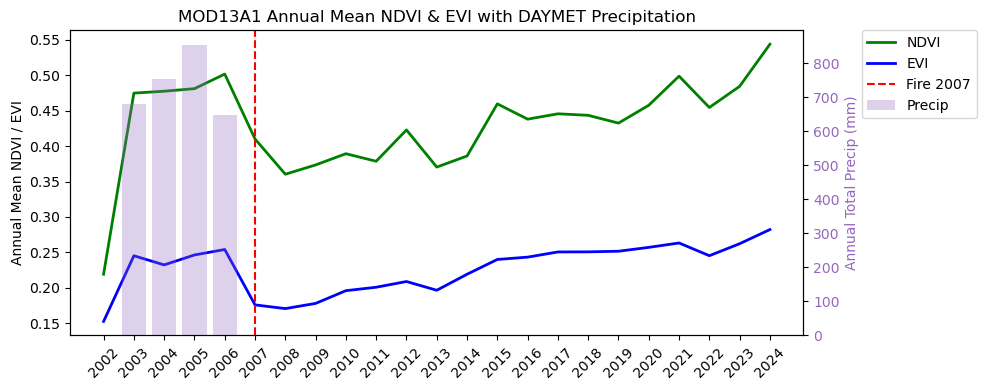

In [ ]:
annual_ndvi = ndvi.mean(dim=['lat', 'lon']).groupby('time.year').mean()
annual_evi  = evi.mean(dim=['lat', 'lon']).groupby('time.year').mean()
annual_prcp = prcp.mean(dim=['lat', 'lon']).groupby('time.year').sum()

years_ndvi = annual_ndvi.year.values
years_prcp = annual_prcp.year.values

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(years_ndvi, annual_ndvi.values, color='green', lw=2, label='NDVI')
ax1.plot(years_ndvi, annual_evi.values,  color='blue',  lw=2, label='EVI')
ax1.set_ylabel('Annual Mean NDVI / EVI')
ax1.axvline(2007, color='red', ls='--', lw=1.5, label='Fire 2007')
ax1.set_xticks(years_ndvi)
ax1.set_xticklabels([str(y) for y in years_ndvi], rotation=45)

ax2 = ax1.twinx()
ax2.bar(years_prcp, annual_prcp.values, alpha=0.3, color='#9467bd', label='Precip')
ax2.set_ylabel('Annual Total Precip (mm)', color='#9467bd')
ax2.tick_params(axis='y', labelcolor='#9467bd')

ax1.set_title('MOD13A1 Annual Mean NDVI & EVI with DAYMET Precipitation')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
             loc='upper left', bbox_to_anchor=(1.08, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

## 4. Regrid Products to a Common Grid

### 4.1 Inspect the 500m Common Grid
The MOD44B Vegetation Continuous Fields Product has a 250m spatial resolution. In order to include this product in the down stream analysis this product will need to be regridded to a common grid. Since the other products in the use case are on a 500 meter grid we will use one of these as a reference and apply that grid to the layers in the MOD44B.  The MOD13A1 16 Day NDVI will be used as the reference layer. 

In [14]:
ref = (mod13a1['_500m_16_days_NDVI']
        .isel(time=0)
        .rio.set_spatial_dims(x_dim='lon', y_dim='lat')
        .rio.write_crs('EPSG:4326'))

Here we can overlay the grid pattern of the reference layer with the pixel centers from the MOD44B. Since the MOD44B is a 250 meter product we will end up with four pixels in each of the 500 meter grid cells.

In [15]:
lon_min, lon_max = -90.90, -90.80
lat_min, lat_max =  48.02,  48.12

def grid_points(da, label, color, size):
      lons = da.lon.values
      lats = da.lat.values
      xx, yy = np.meshgrid(lons, lats)
      mask = ((xx >= lon_min) & (xx <= lon_max) &
              (yy >= lat_min) & (yy <= lat_max))
      return hv.Points((xx[mask], yy[mask]), label=label).opts(
          color=color, size=size, alpha=0.8, tools=['hover'])

ref_lons = ref.lon.values[(ref.lon.values >= lon_min) & (ref.lon.values <= lon_max)]
ref_lats = ref.lat.values[(ref.lat.values >= lat_min) & (ref.lat.values <= lat_max)]

ref_grid = (hv.HLines(ref_lats).opts(color='#1f77b4', line_width=0.8, alpha=0.5) *
              hv.VLines(ref_lons).opts(color='#1f77b4', line_width=0.8, alpha=0.5))

mod44b_plot = (grid_points(tc.isel(time=0), 'MOD44B 250m', '#2ca02c', 4) * ref_grid).opts(
      title='MOD44B 250m — 500m reference grid overlay',
      width=450, height=400, xlabel='Longitude', ylabel='Latitude')

mod44b_plot 

:Overlay
   .Points.MOD44B_250m :Points   [x,y]
   .HLines.I           :HLines   [y]
   .VLines.I           :VLines   [x]

### 4.2 Apply 500 Meter Common Grid
Now that the reference grid is set, we can apply it to the layers in the MOD44B product. The layers that will be regridded include Percent Tree Cover (TC), Percent Non‑Tree Cover (NTC), and Percent Non‑Vegetated (NV). By resampling using the average method, the mean value of the four original MOD44B pixels becomes the pixel value in the new 500‑meter regridded MOD44B layers.

In [16]:
def to_500m(da, resampling):
      return (da
              .rio.set_spatial_dims(x_dim='lon', y_dim='lat')
              .rio.write_crs('EPSG:4326')
              .rio.reproject_match(ref, resampling=resampling))

# MOD44B 250m → 500m (average)
tc_500m  = to_500m(tc,  Resampling.average).rename({'x': 'lon', 'y': 'lat'})
ntv_500m = to_500m(ntv, Resampling.average).rename({'x': 'lon', 'y': 'lat'})
nv_500m  = to_500m(nv,  Resampling.average).rename({'x': 'lon', 'y': 'lat'})



After applying the regrid to the MOD44B Tree Cover products, we plot the mean annual tree cover across the time series, including a marker for the day the fire started. This allows us to visualize trends in tree cover over time.

In [17]:
annual_tc = tc_500m.mean(dim=['lat', 'lon']).groupby('time.year').mean()

ticks = [(yr, str(yr)) for yr in annual_tc.year.values]

fire_dummy = hv.Curve([(2007, float('nan'))],
                        label='Fire (May 2007)').opts(color='red', line_dash='dashed')

(annual_tc.hvplot.line(x='year', label='Tree Cover', color='darkgreen') *
  hv.VLine(2007).opts(color='red', line_dash='dashed') *
fire_dummy).opts(
      title='MOD44B (Regridded) Annual Mean Tree Cover',
      legend_position='top', xticks=ticks, xrotation=45,
      ylabel='% Tree Cover')

:Overlay
   .Curve.Tree_Cover                                       :Curve   [year]   (Percent_Tree_Cover)
   .VLine.I                                                :VLine   [x,y]
   .Curve.Fire_left_parenthesis_May_2007_right_parenthesis :Curve   [x]   (y)

## 5. Perform Analysis

Here we can take our Analysis Ready Outputs from AppEEARS and our Regridded data and perform some basic analysis investigating the vegetation and canopy recovery in the 17 years post fire. To do this we will perform some basic calculations including difference Normalized Burn Ration (dNBR) and visualize canopy recovery of burned pixels. Also we will create a Random Forest Model that attemps to map the fire extent into three recovery classes based upon the vegetation data retreieved from AppEEARS. Lastly a map plot is created showing the mapped recovery classes from the model in areas where dNBR flagged as high severity burn, and tree canopy change in areas flagged as high severity burn.

### 5.1 Calculate Normalized Burn Ratio (NBR)

Burn severity is quantified using the difference Normalized Burn Ratio (dNBR), calculated from the MOD09A1 Terra MODIS 8-Day Surface Reflectance product. NBR is defined as:

$$NBR = \frac{sur\_refl\_b02 - sur\_refl\_b07}{sur\_refl\_b02 + sur\_refl\_b07}$$

where Band 2 is NIR (~841–876 nm) and Band 7 is SWIR (~2105–2155 nm). dNBR is then:

 $$dNBR = NBR_{pre} - NBR_{post}$$

Pre-fire NBR is averaged across four 8-day composites covering June 2006; post-fire NBR is averaged across two composites from June
2007, the first clear imagery following fire containment. Averaging multiple composites reduces noise from residual cloud contamination. Also an output of this calculation is a burn mask that will be used to identify pixels that were burned the mask is calculated as:
 $$burn\_mask = dNBR > 0.10$$

In [18]:
nbr = (b02 - b07) / (b02 + b07)

 # Pre-fire: Jun 2–26 2006
pre_dates  = [cftime.DatetimeJulian(2006, 6, d) for d in [2, 10, 18, 26]]
nbr_pre    = nbr.sel(time=pre_dates).mean('time')

# Post-fire: Jun 2–10 2007 — first clear composites after containment May 12
post_dates = [cftime.DatetimeJulian(2007, 6, d) for d in [2, 10]]
nbr_post   = nbr.sel(time=post_dates).mean('time')


dnbr = (nbr_pre - nbr_post).rename('dnbr')
# ── dNBR burn severity
burn_mask = dnbr > 0.10
print(f'dNBR range    : {float(dnbr.min()):.3f} – {float(dnbr.max()):.3f}')
print(f'Burned pixels : {int(burn_mask.sum())}')

dNBR range    : -0.086 – 1.063
Burned pixels : 2179


### 5.2 Assess Tree Cover Change
Post-fire tree canopy recovery is calculated as the percent change between the
pre-fire (2003–2006) and post-fire (2008–2024) periods:

$$\Delta TC = \frac{TC_{post} - TC_{pre}}{TC_{pre}} \times 100$$

This is derived from the regridded MOD44B Vegetation Continuous Fields tree cover layer.

For this output it is assumed the pre fire are years 2003 - 2006 where as the post fire are years 2008 to 2024.

In [19]:
PRE  = slice('2003', '2006')
POST = slice('2008', '2024')

Now tree cover is calculated.

In [20]:
tc_pre    = tc_500m.sel(time=PRE).mean('time')
tc_post   = tc_500m.sel(time=POST).mean('time')
tc_change = ((tc_post - tc_pre) / tc_pre.where(tc_pre != 0)) * 100

Finally, dNBR and tree cover change are plotted side by side for burned pixels, allowing visual inspection of the relationship between burn severity and post-fire canopy recovery.

In [28]:
opts = dict(x='lon', y='lat', width=420, height=380, tools=['hover'])

dnbr_plot = dnbr.where(burn_mask).hvplot.image(
        cmap='RdYlGn_r', clim=(0.10, 1.0),
        title='Ham Lake Fire 2007 — Burn Severity (dNBR)',
        clabel='dNBR', **opts)

tc_change_plot = tc_change.where(burn_mask).hvplot.image(
        cmap='RdYlGn', clim=(-60, 60),
        title='Tree Cover Change: Pre- vs Post-fire\n (Burned Pixels)',
        clabel='Δ% Tree Cover', **opts)

dnbr_plot + tc_change_plot

:Layout
   .Image.I  :Image   [lon,lat]   (dnbr)
   .Image.II :Image   [lon,lat]   (Percent_Tree_Cover)

### 5.3 Create Random Forest Based Recovery Class Visualization
 

NDVI-based vegetation recovery is computed for each burned pixel and binned into 3 classes.

  1. `ndvi_pre` — mean NDVI per pixel over 2003–2006 (pre-fire baseline)
  2. `ndvi_post` — mean NDVI per pixel over 2008–2024 (post-fire recovery period)
  3. `rec_rate` — percent change from pre- to post-fire, excluding zero pre-fire values

  Recovery classes are defined as:

  | Class | Label | Threshold |
  |-------|-------|-----------|
  | 2 | Fast | NDVI exceeded pre-fire baseline ($rec\_rate > 0\%$) |
  | 1 | Moderate | Partial recovery ($-15\% < rec\_rate \leq 0\%$) |
  | 0 | Slow | Substantially below baseline ($rec\_rate < -15\%$) |

  `rec_class` serves as the target variable ($y$) for the Random Forest classifier.

In [29]:
ndvi_pre  = ndvi.sel(time=PRE).mean('time')
ndvi_post = ndvi.sel(time=POST).mean('time')
rec_rate  = ((ndvi_post - ndvi_pre) / ndvi_pre.where(ndvi_pre != 0)) * 100

rec_class = xr.where(rec_rate > 0,    2,   # Fast — fully recovered past baseline
              xr.where(rec_rate > -15,  1,   # Moderate — partial recovery
                                        0))  # Slow — still well below baseline
rec_class = rec_class.where(burn_mask)
rec_class.name = 'recovery_class'

print(f'Fast     (> 0%)   : {int((rec_class==2).sum())}')
print(f'Moderate (-15–0%) : {int((rec_class==1).sum())}')
print(f'Slow     (< -15%) : {int((rec_class==0).sum())}')



Fast     (> 0%)   : 307
Moderate (-15–0%) : 1355
Slow     (< -15%) : 517


Pre-fire (2003–2006) spatial means are computed for each vegetation variable across all QA-filtered pixels. These serve as the RF input features ($X$), characterizing the vegetation structure of each pixel prior to the Ham Lake Fire:

  - `evi_mean` — Enhanced Vegetation Index (MOD13A1)
  - `lai_mean` — Leaf Area Index (MOD15A2H)
  - `tc_mean` — Percent tree cover (MOD44B)
  - `ntv_mean` — Percent non-tree vegetation (MOD44B)
  - `nv_mean` — Percent non-vegetated (MOD44B)

In [30]:
evi_mean = evi.sel(time=PRE).mean('time')
lai_mean = lai.sel(time=PRE).mean('time')
tc_mean  = tc_500m.sel(time=PRE).mean('time')
ntv_mean = ntv_500m.sel(time=PRE).mean('time')
nv_mean  = nv_500m.sel(time=PRE).mean('time')

All spatial variables are flattened into a pixel-level DataFrame, filtered to burned pixels only (`burn_mask == 1`) and any pixels with missing values dropped. The
resulting DataFrame contains one row per valid burned pixel with the following columns:

**Features ($X$):** `evi`, `lai`, `tc`, `ntv`, `dnbr`
**Target ($y$):** `recovery_class`
**Diagnostic:** `rec_rate` (carried for validation, not used in modeling)

Dropped pixels reflect MOD44B edge artifacts and LAI QA failures where valid
observations were insufficient to produce a mean.

In [31]:
def to_vec(da): return da.values.ravel()

df = pd.DataFrame({
        'evi':            to_vec(evi_mean),
        'lai':            to_vec(lai_mean),
        'tc':             to_vec(tc_mean),
        'ntv':            to_vec(ntv_mean),
        'dnbr':           to_vec(dnbr),
        'recovery_class': to_vec(rec_class),
        'rec_rate':       to_vec(rec_rate),
        'tc_change':      to_vec(tc_change),
    })
df = df[to_vec(burn_mask) == 1].dropna()
print(f'Modeling on {len(df)} burned pixels')
print(f'Burned pixels        : {int(burn_mask.sum())}')
print(f'Valid modeling pixels: {len(df)} ({len(df)/int(burn_mask.sum())*100:.1f}%)')
print(f'Dropped (NaN)        : {int(burn_mask.sum()) - len(df)} — MOD44B edge artifacts and LAI QA failures')

Modeling on 1446 burned pixels
Burned pixels        : 2179
Valid modeling pixels: 1446 (66.4%)
Dropped (NaN)        : 733 — MOD44B edge artifacts and LAI QA failures


A Random Forest classifier is trained to predict recovery class from pre-fire vegetation structure and burn severity. The dataset is split 80/20 into training and test sets, stratified by class to preserve class proportions. `class_weight='balanced'` corrects for class imbalance between Slow (n=80), Moderate (n=170), and Fast (n=40) pixels.

**Features ($X$):** `evi`, `lai`, `tc`, `ntv`, `dnbr`
 **Target ($y$):** `recovery_class` (0=Slow, 1=Moderate, 2=Fast)
**Model:** Random Forest, 300 trees

In [32]:
X = df[['evi', 'lai', 'tc', 'ntv', 'dnbr']]
y = df['recovery_class'].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                                stratify=y, random_state=42)
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Random Forest predictions are generated for all valid burned pixels and mapped back to the original spatial grid. Pixels dropped during QA filtering remain `NaN`. The resulting
map shows the RF-predicted recovery class for each burned pixel, with class colors indicating trajectory:

- **Red** — Slow: NDVI still substantially below pre-fire baseline
- **Orange** — Moderate: partial recovery
- **Green** — Fast: NDVI exceeded pre-fire baseline

In [33]:
df['rf_pred'] = rf.predict(df[['evi', 'lai', 'tc', 'ntv', 'dnbr']])

all_vals = np.full(to_vec(burn_mask).shape, np.nan)
all_vals[df.index] = df['rf_pred'].values

rf_class = xr.DataArray(
        all_vals.reshape(burn_mask.shape),
        coords={'lat': burn_mask.lat, 'lon': burn_mask.lon},
        dims=['lat', 'lon'],
        name='rf_class'
      )

print(f"RF predictions mapped: {int((~np.isnan(rf_class.values)).sum())} pixels")

rf_class.hvplot.image(x='lon', y='lat',
          cmap=['#d7191c', '#fdae61', '#1a9641'],
          clim=(-0.5, 2.5), width=500, height=400,
          title='RF Predicted Recovery Class (2008–2024 vs 2003–2006)',
          clabel='0=Slow  1=Moderate  2=Fast', tools=['hover']).opts(
          colorbar_opts={'ticker': FixedTicker(ticks=[0, 1, 2])})

RF predictions mapped: 1446 pixels


:Image   [lon,lat]   (rf_class)

Here we plot Random Forest predicted recovery class (Slow/Moderate/Fast) masked to only the highest severity burned pixels (dNBR > 0.66),
showing where the worst-burned areas ended up in each recovery trajectory. MOD44B tree cover change masked to only Random Forest predicted slow recovery pixels, showing the actual canopy loss in areas the model flagged as slow-recovering, validating that areas flagged as slow-recovering by the model correspond to actual canopy loss in an independent data source.

In [41]:
high_sev_mask = burn_mask & (dnbr > 0.66)

opts = dict(geo=True, alpha=0.8, width=550, height=460,
              tools=['hover'], tiles='EsriWorldLightGrayBase')

raster = rf_class.where(high_sev_mask).hvplot.image(
      x='lon', y='lat',
      cmap=['#d7191c', '#fdae61', '#1a9641'],
      clim=(-0.5, 2.5),
      colorbar=True, clabel='Slow | Moderate | Fast',
      title='RF Recovery Class — High Severity Only (dNBR > 0.66)',
      **opts)

raster = raster.opts(
      hv.opts.Image(colorbar_opts={'ticker': FixedTicker(ticks=[0, 1, 2])})
  )

slow_mask = (rf_class == 0) & burn_mask

tc_raster = tc_change.where(slow_mask).hvplot.image(
        x='lon', y='lat',
        cmap='RdYlGn', clim=(-60, 60),
        colorbar=True, clabel='Δ% Tree Cover',
        title='Tree Cover Change — RF Predicted Slow Recovery',
        **opts)


fire_gdf = gpd.read_file('ham_lake_fire.geojson')

perimeter = fire_gdf.hvplot.polygons(
      geo=True, fill_color=None, fill_alpha=0,
      line_color='black', line_width=2)

lakes = [
      (-90.809, 48.065, 'Ham Lake'),
      (-90.6144, 48.242, 'Northern Lake'),
      (-90.725, 48.092, 'Gunflint Lake'),
      (-90.958, 48.128, 'Seagull Lake'),
  ]
lake_labels = gv.Labels(
      [(lon, lat, name) for lon, lat, name in lakes],
      kdims=['lon', 'lat'], vdims=['text']
  ).opts(text_color='blue', text_font_size='9pt',
         text_font_style='bold', text_align='center')

(raster * perimeter * lake_labels + tc_raster * perimeter * lake_labels).cols(2)


:Layout
   .Overlay.I  :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [lon,lat]   (rf_class)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Labels.I   :Labels   [lon,lat]   (text)
   .Overlay.II :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Image.I    :Image   [lon,lat]   (Percent_Tree_Cover)
      .Polygons.I :Polygons   [Longitude,Latitude]
      .Labels.I   :Labels   [lon,lat]   (text)

Success! You have learned how to read, process, transform, and leverage AppEEARS Analysis‑Ready Outputs to perform spatial analysis within a region of interest. You can now build upon this work to support your own analyses using AppEEARS outputs.

## Contact Info  

Email: LPDAAC@usgs.gov  
Voice: +1-866-573-3222  
Organization: Land Processes Distributed Active Archive Center (LP DAAC)¹  
Website: <https://www.earthdata.nasa.gov/centers/lp-daac>  

¹Work performed under USGS contract 140G0126D0001 for NASA contract NNG14HH33I.